In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy.linalg as linalg
from src.pt import *
import ot

%load_ext autoreload

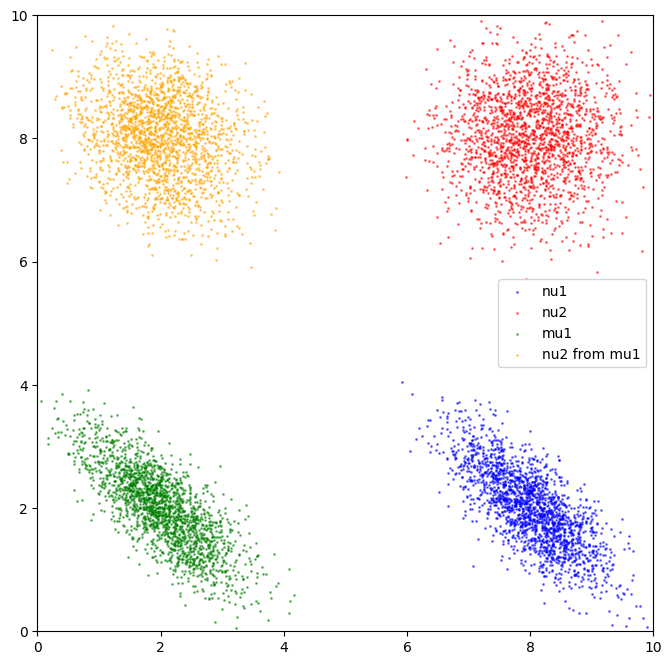

In [8]:
%autoreload 2
# test with samples from normal
n_samples_nu_1 = 2000
n_samples_nu_2 = 2000
n_samples_mu_1 = 2000

mean_nu1 = np.array([8, 2])
sigma_nu1 = np.array([[0.4, -0.3], [-0.3, 0.4]])

mean_nu2 = np.array([8, 8])
sigma_nu2 = np.array([[0.5, 0.0], [0.0, 0.5]])

mean_mu1 = np.array([2, 2])
sigma_mu1 = np.array([[0.4, -0.3], [-0.3, 0.4]])

# sample n_samples from nu_1, mu_1 and nu_2
nu1_samples = np.random.multivariate_normal(mean_nu1, sigma_nu1, size=n_samples_nu_1)
nu2_samples = np.random.multivariate_normal(mean_nu2, sigma_nu2, size=n_samples_nu_2)
mu1_samples = np.random.multivariate_normal(mean_mu1, sigma_mu1, size=n_samples_mu_1)

# obtain logmap from nu1 to nu2 and from nu1 to mu1
nu1_measure = EmpiricalMeasure(nu1_samples, np.ones(n_samples_nu_1) / n_samples_nu_1)
nu2_measure = EmpiricalMeasure(nu2_samples, np.ones(n_samples_nu_2) / n_samples_nu_2)
mu1_measure = EmpiricalMeasure(mu1_samples, np.ones(n_samples_mu_1) / n_samples_mu_1)

tangent_nu1_nu2 = wasserstein_logmap(nu1_measure, nu2_measure)
tangent_nu1_mu1 = wasserstein_logmap(nu1_measure, mu1_measure)

# parallel transport tangent_nu1_nu2 from nu1 to mu1
tangent_nu2_mu1 = tangent_nu1_nu2.parallel_transport(nu1_measure, mu1_measure, n=10, project=True)
# compute the exponential map of the transported tangent at mu1
nu2_from_mu1 = tangent_nu2_mu1.wasserstein_expmap()

# visualize by plotting and color-coding the measures (no tangents)
plt.figure(figsize=(8, 8))
plt.scatter(nu1_measure.locs[:, 0], nu1_measure.locs[:, 1], color='blue', alpha=0.5, label='nu1', s=1)
plt.scatter(nu2_measure.locs[:, 0], nu2_measure.locs[:, 1], color='red', alpha=0.5, label='nu2', s=1)
plt.scatter(mu1_measure.locs[:, 0], mu1_measure.locs[:, 1], color='green', alpha=0.5, label='mu1', s=1)
plt.scatter(nu2_from_mu1.locs[:, 0], nu2_from_mu1.locs[:, 1], color='orange', alpha=0.5, label='nu2 from mu1', s=1)
# set axis limits for better visualization
plt.xlim(0, 10)
plt.ylim(0, 10)
# set aspect ratio to equal for proper distance visualization
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()

